# 🛡️ GraphShields — Final Experiment (Leakage-Safe + Balanced Evaluation)
AMAD Hackathon · one-shot rerun · all artifacts saved to Drive under `GraphShields/results_final/`

Sections: 1 Setup · 2 Data · 3 Temporal Split · 4 XGBoost + Threshold · 5 GATv2 · 6 Hybrid · 7 Evaluation Table · 8 Export


## 1. Setup & Imports

In [1]:
import os, json, warnings
warnings.filterwarnings("ignore")
import torch

if "COLAB_GPU" in os.environ:
    TORCH = torch.__version__.split("+")[0]
    CUDA  = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"
    if torch.cuda.is_available():
        os.system(f"pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html")
    os.system("pip install -q torch-geometric shap")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from torch.nn import BatchNorm1d, LeakyReLU, Dropout
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, precision_recall_curve, auc)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 2. Mount Drive & Load Dataset

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import zipfile
DRIVE_BASE  = "/content/drive/MyDrive"
ZIP_PATH    = f"{DRIVE_BASE}/GraphShields/data/elliptic_dataset/archive.zip"
EXTRACT_DIR = "/content/elliptic"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

# Locate CSVs (handles nested subdirectory)
for root, _, files in os.walk(EXTRACT_DIR):
    if "elliptic_txs_features.csv" in files:
        DATA_DIR = root
        break

df_feat  = pd.read_csv(f"{DATA_DIR}/elliptic_txs_features.csv", header=None)
df_cls   = pd.read_csv(f"{DATA_DIR}/elliptic_txs_classes.csv")
df_edges = pd.read_csv(f"{DATA_DIR}/elliptic_txs_edgelist.csv")

# Column names: txId + V1…V166 (V1 = time step per Weber et al. 2019)
df_feat.columns = ["txId"] + [f"V{i}" for i in range(1, 167)]

print(f"Features : {df_feat.shape}  |  Classes : {df_cls.shape}  |  Edges : {df_edges.shape}")
print(df_cls["class"].value_counts().to_string())


Mounted at /content/drive
Features : (203769, 167)  |  Classes : (203769, 2)  |  Edges : (234355, 2)
class
unknown    157205
2           42019
1            4545


## 3. Data Preparation & Temporal Split

Label encoding: class 1 → illicit (1), class 2 → licit (0). Unknown transactions excluded from training and evaluation entirely.

Temporal split (past→future, no shuffle, no leakage):
- **Train**: time step ≤ 30
- **Val**:   time step 31–39
- **Test**:  time step ≥ 40


In [3]:
# Merge features + labels on txId
df_cls["label"] = df_cls["class"].map({"1": 1, "2": 0, 1: 1, 2: 0})
df = df_feat.merge(df_cls[["txId", "label"]], on="txId", how="left")

# Drop unknowns — never used in training, val, or test
df_labeled = df[df["label"].notna()].copy()
df_labeled["label"] = df_labeled["label"].astype(int)

# V1 is the time step
df_labeled["time_step"] = df_labeled["V1"].astype(int)

FEAT_COLS = [f"V{i}" for i in range(1, 167)]   # all 166 raw features

train_df = df_labeled[df_labeled["time_step"] <= 30].reset_index(drop=True)
val_df   = df_labeled[(df_labeled["time_step"] >= 31) & (df_labeled["time_step"] <= 39)].reset_index(drop=True)
test_df  = df_labeled[df_labeled["time_step"] >= 40].reset_index(drop=True)

for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    ill = (d["label"]==1).sum(); lic = (d["label"]==0).sum()
    print(f"{name:5s}: {len(d):6,} txns  |  illicit {ill:,} ({ill/len(d)*100:.1f}%)  |  licit {lic:,}")


Train: 26,905 txns  |  illicit 2,954 (11.0%)  |  licit 23,951
Val  :  8,475 txns  |  illicit 955 (11.3%)  |  licit 7,520
Test : 11,184 txns  |  illicit 636 (5.7%)  |  licit 10,548


## 4. XGBoost — Train + Threshold Optimisation (Val Only)

In [4]:
X_tr  = train_df[FEAT_COLS].values;  y_tr  = train_df["label"].values
X_val = val_df[FEAT_COLS].values;    y_val = val_df["label"].values
X_te  = test_df[FEAT_COLS].values;   y_te  = test_df["label"].values

# scale_pos_weight from TRAINING split only — no leakage
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight (train only): {spw:.4f}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    random_state=42, tree_method="hist", eval_metric="logloss",
    early_stopping_rounds=20, verbosity=0,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best XGB iteration: {xgb.best_iteration}")


scale_pos_weight (train only): 8.1080
Best XGB iteration: 299


In [5]:
# Threshold optimisation on VAL only — no test data touched
val_probs_xgb = xgb.predict_proba(X_val)[:, 1]

best_thresh, best_macro = 0.5, 0.0
thresh_records = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = (val_probs_xgb >= t).astype(int)
    macro = f1_score(y_val, preds, average="macro", zero_division=0)
    p0,r0,f0 = [precision_score(y_val,preds,pos_label=0,zero_division=0),
                recall_score(y_val,preds,pos_label=0,zero_division=0),
                f1_score(y_val,preds,pos_label=0,zero_division=0)]
    p1,r1,f1_ = [precision_score(y_val,preds,pos_label=1,zero_division=0),
                 recall_score(y_val,preds,pos_label=1,zero_division=0),
                 f1_score(y_val,preds,pos_label=1,zero_division=0)]
    thresh_records.append({"threshold":t,"macro_f1":macro,
                           "licit_f1":f0,"illicit_f1":f1_,
                           "licit_prec":p0,"licit_rec":r0,
                           "illicit_prec":p1,"illicit_rec":r1})
    if macro > best_macro:
        best_macro, best_thresh = macro, t

print(pd.DataFrame(thresh_records).to_string(index=False))
print(f"\nBest threshold (val macro F1): {best_thresh}  →  macro F1 = {best_macro:.4f}")


 threshold  macro_f1  licit_f1  illicit_f1  licit_prec  licit_rec  illicit_prec  illicit_rec
       0.1  0.868972  0.963049    0.774895    0.995881   0.932314      0.645296     0.969634
       0.2  0.912775  0.977594    0.847956    0.995588   0.960239      0.755319     0.966492
       0.3  0.934786  0.983995    0.885577    0.995374   0.972872      0.818667     0.964398
       0.4  0.950196  0.988147    0.912246    0.995279   0.981117      0.866290     0.963351
       0.5  0.960263  0.990791    0.929735    0.994374   0.987234      0.904856     0.956021
       0.6  0.967899  0.992674    0.943123    0.994264   0.991090      0.931563     0.954974
       0.7  0.973561  0.994088    0.953034    0.993099   0.995080      0.960638     0.945550
       0.8  0.974802  0.994428    0.955176    0.992059   0.996809      0.973885     0.937173
       0.9  0.970624  0.993650    0.947598    0.988550   0.998803      0.989738     0.908901

Best threshold (val macro F1): 0.8  →  macro F1 = 0.9748


In [6]:
# Final XGBoost test evaluation with best threshold
test_probs_xgb = xgb.predict_proba(X_te)[:, 1]
test_preds_xgb = (test_probs_xgb >= best_thresh).astype(int)

xgb_metrics = {
    "model": "XGBoost",
    "threshold": best_thresh,
    "licit_f1":   float(f1_score(y_te, test_preds_xgb, pos_label=0, zero_division=0)),
    "illicit_f1": float(f1_score(y_te, test_preds_xgb, pos_label=1, zero_division=0)),
    "macro_f1":   float(f1_score(y_te, test_preds_xgb, average="macro", zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_te, test_probs_xgb)),
}
print(xgb_metrics)


{'model': 'XGBoost', 'threshold': 0.8, 'licit_f1': 0.9849246231155779, 'illicit_f1': 0.7013953488372093, 'macro_f1': 0.8431599859763936, 'roc_auc': 0.8749549826728009}


## 5. GATv2 — Architecture, Training (Macro F1 Early Stopping), Evaluation

Early stopping uses **val macro F1** (not illicit-only F1), so the model is not biased toward flooding the licit class with false positives to maximise fraud recall.

In [7]:
class GraphShieldsGATv2(torch.nn.Module):
    def __init__(self, in_channels, hidden=16, heads=8, dropout=0.3):
        super().__init__()
        self.conv1  = GATv2Conv(in_channels, hidden, heads=heads, dropout=dropout)
        self.bn1    = BatchNorm1d(hidden * heads)
        self.act    = LeakyReLU(0.2)
        self.drop   = Dropout(dropout)
        self.conv2  = GATv2Conv(hidden * heads, 1, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x); x = self.act(x); x = self.drop(x)
        return self.conv2(x, edge_index)          # raw logits, shape [N,1]

    def embeddings(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x); x = self.act(x); x = self.drop(x)
        return x                                   # [N, hidden*heads]


In [8]:
# Build PyG graph — all nodes (labeled + unlabeled) for message passing
tx_to_idx = {tx: i for i, tx in enumerate(df_feat["txId"])}

x_all = torch.tensor(df_feat[FEAT_COLS].values, dtype=torch.float)

# Labels for ALL nodes (NaN for unknowns — masked out in loss)
label_all = df["label"].values  # aligned to df_feat row order
y_all = torch.tensor(
    np.where(pd.isna(label_all), -1, label_all), dtype=torch.float
).unsqueeze(1)

# Edge index
s = df_edges["txId1"].map(tx_to_idx).dropna().astype(int)
d = df_edges["txId2"].map(tx_to_idx).dropna().astype(int)
valid = s.index.intersection(d.index)
edge_index = torch.tensor(np.array([s.loc[valid].values, d.loc[valid].values]), dtype=torch.long)

# Temporal masks (labeled nodes only)
time_all = df_feat["V1"].values  # time step per node

def make_mask(tx_ids):
    idxs = [tx_to_idx[t] for t in tx_ids if t in tx_to_idx]
    m = torch.zeros(len(df_feat), dtype=torch.bool)
    m[idxs] = True
    return m

train_mask = make_mask(train_df["txId"])
val_mask   = make_mask(val_df["txId"])
test_mask  = make_mask(test_df["txId"])

graph = Data(x=x_all, edge_index=edge_index, y=y_all,
             train_mask=train_mask, val_mask=val_mask, test_mask=test_mask).to(device)

print(f"Graph: {graph.num_nodes:,} nodes  {graph.num_edges:,} edges  {graph.num_features} features")
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")


Graph: 203,769 nodes  234,355 edges  166 features
Train: 26,905  Val: 8,475  Test: 11,184


In [9]:
# Class weights from TRAINING nodes only
tr_labels = y_all[train_mask].numpy().flatten()
w_illicit = float((tr_labels == 0).sum() / (tr_labels == 1).sum())
# Cap weight — avoids GATv2 overcorrecting toward false positives
w_illicit = min(w_illicit, 5.0)
print(f"Illicit pos_weight (capped at 5): {w_illicit:.4f}")

pos_weight = torch.tensor([w_illicit]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

gat = GraphShieldsGATv2(in_channels=graph.num_features).to(device)
opt = torch.optim.Adam(gat.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

EPOCHS = 100
PATIENCE = 15
best_val_macro, patience_ctr, best_state = 0.0, 0, None

for epoch in range(1, EPOCHS + 1):
    # Train
    gat.train()
    opt.zero_grad()
    logits = gat(graph.x, graph.edge_index)
    loss = loss_fn(logits[train_mask], graph.y[train_mask])
    loss.backward(); opt.step()

    # Val
    gat.eval()
    with torch.no_grad():
        val_logits = gat(graph.x, graph.edge_index)[val_mask]
        val_probs  = torch.sigmoid(val_logits).cpu().numpy().flatten()
        val_preds  = (val_probs >= 0.5).astype(int)
        val_true   = graph.y[val_mask].cpu().numpy().flatten().astype(int)
        val_macro  = f1_score(val_true, val_preds, average="macro", zero_division=0)
        val_loss   = loss_fn(val_logits, graph.y[val_mask]).item()

    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        ill_f1 = f1_score(val_true, val_preds, pos_label=1, zero_division=0)
        print(f"Ep {epoch:03d} | TrainLoss {loss.item():.4f} | ValLoss {val_loss:.4f} "
              f"| Val MacroF1 {val_macro:.4f} | Val IllicitF1 {ill_f1:.4f}")

    # Early stopping on MACRO F1
    if val_macro > best_val_macro:
        best_val_macro = val_macro
        best_state = {k: v.clone() for k, v in gat.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}. Best val macro F1: {best_val_macro:.4f}")
            break

gat.load_state_dict(best_state)
gat.eval()
print(f"Loaded best weights (val macro F1 = {best_val_macro:.4f})")


Illicit pos_weight (capped at 5): 5.0000
Ep 001 | TrainLoss 1.2024 | ValLoss 2.7191 | Val MacroF1 0.1317 | Val IllicitF1 0.2073
Ep 010 | TrainLoss 0.7517 | ValLoss 1.5525 | Val MacroF1 0.3036 | Val IllicitF1 0.2448
Ep 020 | TrainLoss 0.6746 | ValLoss 1.1899 | Val MacroF1 0.3997 | Val IllicitF1 0.2791
Ep 030 | TrainLoss 0.6413 | ValLoss 0.9606 | Val MacroF1 0.4700 | Val IllicitF1 0.3138
Ep 040 | TrainLoss 0.6111 | ValLoss 0.8763 | Val MacroF1 0.4997 | Val IllicitF1 0.3323
Ep 050 | TrainLoss 0.5843 | ValLoss 0.8467 | Val MacroF1 0.5088 | Val IllicitF1 0.3380
Ep 060 | TrainLoss 0.5631 | ValLoss 0.8113 | Val MacroF1 0.5228 | Val IllicitF1 0.3479
Ep 070 | TrainLoss 0.5401 | ValLoss 0.7911 | Val MacroF1 0.5307 | Val IllicitF1 0.3538
Ep 080 | TrainLoss 0.5196 | ValLoss 0.7645 | Val MacroF1 0.5418 | Val IllicitF1 0.3620
Ep 090 | TrainLoss 0.5098 | ValLoss 0.7400 | Val MacroF1 0.5524 | Val IllicitF1 0.3703
Ep 100 | TrainLoss 0.4990 | ValLoss 0.7186 | Val MacroF1 0.5628 | Val IllicitF1 0.3782
Lo

In [10]:
# GATv2 test evaluation
with torch.no_grad():
    all_logits = gat(graph.x, graph.edge_index)
    gat_emb    = gat.embeddings(graph.x, graph.edge_index).cpu().numpy()  # [N, 128]

test_logits_gat = all_logits[test_mask]
test_probs_gat  = torch.sigmoid(test_logits_gat).cpu().numpy().flatten()
test_preds_gat  = (test_probs_gat >= 0.5).astype(int)
y_te_gat        = graph.y[test_mask].cpu().numpy().flatten().astype(int)

gat_metrics = {
    "model": "GATv2",
    "threshold": 0.5,
    "licit_f1":   float(f1_score(y_te_gat, test_preds_gat, pos_label=0, zero_division=0)),
    "illicit_f1": float(f1_score(y_te_gat, test_preds_gat, pos_label=1, zero_division=0)),
    "macro_f1":   float(f1_score(y_te_gat, test_preds_gat, average="macro", zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_te_gat, test_probs_gat)),
}
print(gat_metrics)


{'model': 'GATv2', 'threshold': 0.5, 'licit_f1': 0.6248133480490814, 'illicit_f1': 0.17027997128499642, 'macro_f1': 0.3975466596670389, 'roc_auc': 0.8036264438338784}


## 6. Hybrid Ensemble (XGBoost prob + GATv2 prob, weight tuned on Val)

In [11]:
# GATv2 val probs for weight search
with torch.no_grad():
    val_probs_gat = torch.sigmoid(
        gat(graph.x, graph.edge_index)[val_mask]
    ).cpu().numpy().flatten()

# XGBoost val probs (already computed above as val_probs_xgb)
best_alpha, best_hybrid_macro = 0.5, 0.0
for alpha in np.arange(0.1, 1.0, 0.1):
    combined = alpha * val_probs_xgb + (1 - alpha) * val_probs_gat
    preds = (combined >= best_thresh).astype(int)
    macro = f1_score(y_val, preds, average="macro", zero_division=0)
    if macro > best_hybrid_macro:
        best_hybrid_macro, best_alpha = macro, alpha

print(f"Best alpha (XGB weight): {best_alpha:.1f}  →  val macro F1 = {best_hybrid_macro:.4f}")

# Test evaluation
hybrid_probs = best_alpha * test_probs_xgb + (1 - best_alpha) * test_probs_gat
hybrid_preds = (hybrid_probs >= best_thresh).astype(int)

hybrid_metrics = {
    "model": "Hybrid",
    "xgb_alpha": float(best_alpha),
    "threshold": best_thresh,
    "licit_f1":   float(f1_score(y_te, hybrid_preds, pos_label=0, zero_division=0)),
    "illicit_f1": float(f1_score(y_te, hybrid_preds, pos_label=1, zero_division=0)),
    "macro_f1":   float(f1_score(y_te, hybrid_preds, average="macro", zero_division=0)),
    "roc_auc":    float(roc_auc_score(y_te, hybrid_probs)),
}
print(hybrid_metrics)


Best alpha (XGB weight): 0.9  →  val macro F1 = 0.9756
{'model': 'Hybrid', 'xgb_alpha': 0.9, 'threshold': 0.8, 'licit_f1': 0.9847339001362205, 'illicit_f1': 0.6987951807228916, 'macro_f1': 0.8417645404295561, 'roc_auc': 0.8644768271072283}


## 7. Final Evaluation Table & Plots

In [12]:
rows = [xgb_metrics, gat_metrics, hybrid_metrics]
summary_df = pd.DataFrame(rows)[["model","licit_f1","illicit_f1","macro_f1","roc_auc"]]
summary_df.columns = ["Model","Class 0 F1 (Licit)","Class 1 F1 (Illicit)","Macro F1","ROC-AUC"]
print("\n" + "="*65)
print("  GraphShields — Final Evaluation Results (Temporal Split)")
print("="*65)
print(summary_df.to_string(index=False))
print("="*65)



  GraphShields — Final Evaluation Results (Temporal Split)
  Model  Class 0 F1 (Licit)  Class 1 F1 (Illicit)  Macro F1  ROC-AUC
XGBoost            0.984925              0.701395  0.843160 0.874955
  GATv2            0.624813              0.170280  0.397547 0.803626
 Hybrid            0.984734              0.698795  0.841765 0.864477


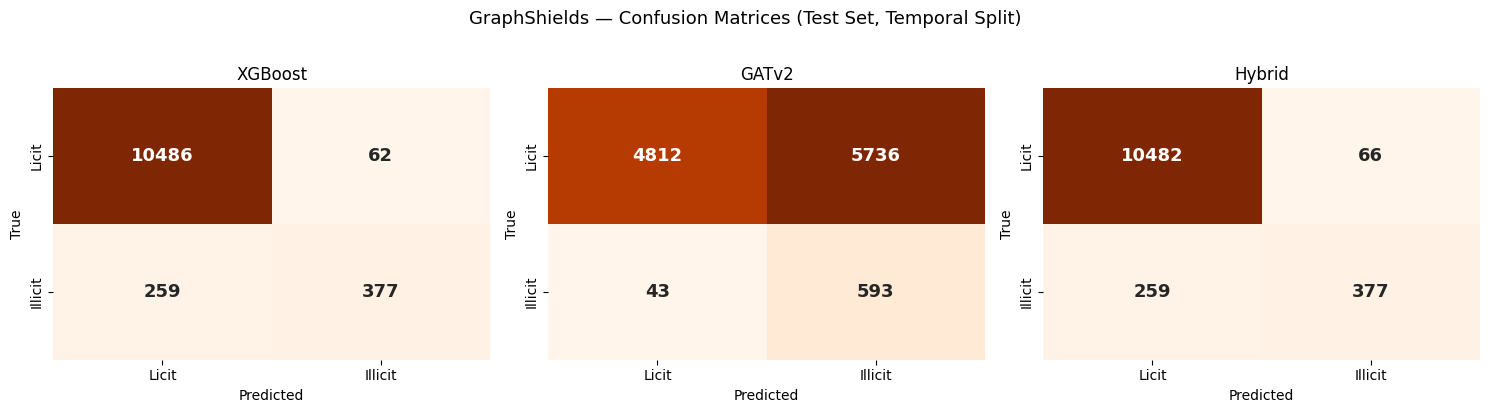

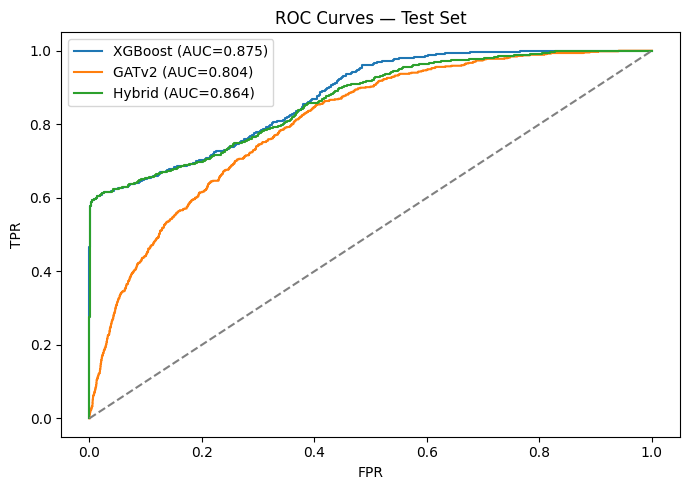

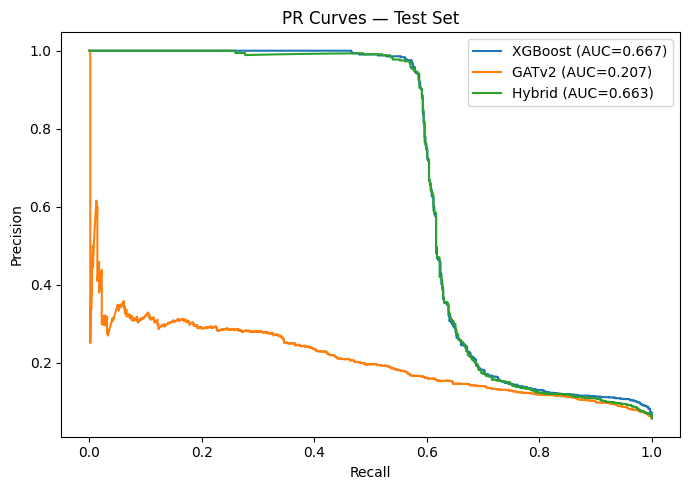

In [13]:
RESULTS_ROOT = f"{DRIVE_BASE}/GraphShields/results_final"
DIRS = {k: f"{RESULTS_ROOT}/{k}" for k in
        ["models","data","predictions","metrics","threshold","embeddings"]}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

# --- Confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, yt, yp) in zip(axes, [
    ("XGBoost", y_te, test_preds_xgb),
    ("GATv2",   y_te_gat, test_preds_gat),
    ("Hybrid",  y_te, hybrid_preds),
]):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                annot_kws={"size":13,"weight":"bold"})
    ax.set_title(f"{name}"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticklabels(["Licit","Illicit"]); ax.set_yticklabels(["Licit","Illicit"])
plt.suptitle("GraphShields — Confusion Matrices (Test Set, Temporal Split)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{DIRS['metrics']}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, yt, yp in [("XGBoost",y_te,test_probs_xgb),("GATv2",y_te_gat,test_probs_gat),("Hybrid",y_te,hybrid_probs)]:
    fpr,tpr,_ = roc_curve(yt,yp); ax.plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],"--",color="grey"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves — Test Set"); ax.legend()
plt.tight_layout()
plt.savefig(f"{DIRS['metrics']}/roc_curve.png", dpi=150)
plt.show()

# --- PR curves ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, yt, yp in [("XGBoost",y_te,test_probs_xgb),("GATv2",y_te_gat,test_probs_gat),("Hybrid",y_te,hybrid_probs)]:
    prec,rec,_ = precision_recall_curve(yt,yp); ax.plot(rec,prec,label=f"{name} (AUC={auc(rec,prec):.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curves — Test Set"); ax.legend()
plt.tight_layout()
plt.savefig(f"{DIRS['metrics']}/pr_curve.png", dpi=150)
plt.show()


## 8. Export All Artifacts to Drive (No Future Retraining Needed)

In [ ]:
# Models
joblib.dump(xgb, f"{DIRS['models']}/xgb_model.pkl")
torch.save(best_state, f"{DIRS['models']}/gatv2_weights.pt")

# Split ID files
train_df[["txId","label","time_step"]].to_csv(f"{DIRS['data']}/train_ids.csv", index=False)
val_df[["txId","label","time_step"]].to_csv(f"{DIRS['data']}/val_ids.csv", index=False)
test_df[["txId","label","time_step"]].to_csv(f"{DIRS['data']}/test_ids.csv", index=False)

# Predictions
pd.DataFrame({"txId": test_df["txId"], "true_label": y_te,
              "prob": test_probs_xgb, "pred": test_preds_xgb}
             ).to_csv(f"{DIRS['predictions']}/xgb_predictions.csv", index=False)

pd.DataFrame({"txId": test_df["txId"], "true_label": y_te_gat,
              "prob": test_probs_gat, "pred": test_preds_gat}
             ).to_csv(f"{DIRS['predictions']}/gatv2_predictions.csv", index=False)

pd.DataFrame({"txId": test_df["txId"], "true_label": y_te,
              "prob": hybrid_probs, "pred": hybrid_preds}
             ).to_csv(f"{DIRS['predictions']}/hybrid_predictions.csv", index=False)

# Metrics
final_metrics = {
    "split": {"train_max_step": 30, "val_steps": "31-39", "test_min_step": 40},
    "XGBoost": xgb_metrics,
    "GATv2":   gat_metrics,
    "Hybrid":  hybrid_metrics,
    "summary": summary_df.to_dict(orient="records"),
}
with open(f"{DIRS['metrics']}/final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

# Threshold
with open(f"{DIRS['threshold']}/best_threshold.json", "w") as f:
    json.dump({"best_threshold": best_thresh, "best_val_macro_f1": best_macro,
               "all_thresholds": thresh_records}, f, indent=2)

# Embeddings (full graph, all nodes — GNNExplainer needs this)
np.save(f"{DIRS['embeddings']}/gat_embeddings.npy", gat_emb)

# Transaction IDs with split labels — for explainability notebooks
tx_id_series = df_feat["txId"].reset_index(drop=True)
split_col = pd.Series("unlabeled", index=range(len(tx_id_series)))
for mask_arr, name in [(train_mask.numpy(), "train"),
                       (val_mask.numpy(),   "val"),
                       (test_mask.numpy(),  "test")]:
    split_col[mask_arr] = name
label_col = pd.Series(y_all.numpy().flatten().astype(int))
pd.DataFrame({
    "node_idx": range(len(tx_id_series)),
    "txId":     tx_id_series,
    "label":    label_col,
    "split":    split_col,
}).to_csv(f"{DIRS['embeddings']}/transaction_ids.csv", index=False)

# graph/ — pyg_graph.pt (contains .x .edge_index .y) + transaction_mapping.csv
os.makedirs(f"{RESULTS_ROOT}/graph", exist_ok=True)
torch.save(graph.cpu(), f"{RESULTS_ROOT}/graph/pyg_graph.pt")
pd.DataFrame({
    "node_index": range(len(df_feat)),
    "txId":       df_feat["txId"].values,
}).to_csv(f"{RESULTS_ROOT}/graph/transaction_mapping.csv", index=False)

# XGBoost feature matrix for SHAP (test split only, with txId)
xgb_feat_df = pd.DataFrame(X_te, columns=FEAT_COLS)
xgb_feat_df.insert(0, "txId", test_df["txId"].values)
xgb_feat_df.to_csv(f"{DIRS['predictions']}/xgb_test_features.csv", index=False)

print("\nExport complete. Artifact tree:")
for root, _, files in os.walk(RESULTS_ROOT):
    for fname in sorted(files):
        rel = os.path.relpath(os.path.join(root, fname), RESULTS_ROOT)
        print(f"  results_final/{rel}")
